# File for dimensionality reduction and clustering

#### Importing packages:

In [1]:
import matplotlib.pyplot as plt
from os import listdir
from os.path import isfile, join
import pandas as pd
import os
import numpy as np
import umap
from sklearn.datasets import fetch_openml
import seaborn as sns
from sklearn import preprocessing
from sklearn import cluster
from sklearn import manifold
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

#### Getting data imported:

In [11]:
#Using this to get the photo names:
image_example_path = "images"
image_file_names = [f for f in listdir(image_example_path) if isfile(join(image_example_path, f))]

In [12]:
#printed so it´s not only me that can see it(change path to the one that works for you if you want the code to work)
print(image_file_names)

['0_left.webp', '0_right.webp', '1_left.webp', '1_right.webp', '2_left.webp', '2_right.webp', '3_left.webp', '3_right.webp', '4_left.webp', '4_right.webp', '5_left.webp', '5_right.webp', '6_left.webp', '6_right.webp', '7_left.webp', '7_right.webp', '8_left.webp', '8_right.webp', '9_left.webp', '9_right.webp']


In [7]:
#Next, we´ll get the low-res photos imported(doesnt take long. for my computer: 7.5s)

#Creating a list for the photos with the corresponding dates and image names as well(crude way of being able to see which are outliers.
#Needs to be done better, really. If someone has the time, feel free to find a better way of doing things)
image_Data_low_res = []

#Next, a list for the metadata i want(for now, at least. there´s certainly going to be a better way of doing this later):
metadata_image_clustering = []


#Folder with folders of images:
base_folder = r"../data\scrandle_padded_low_res_data"
#Meta data folders(yes, a bit inefficient):
meta_folder = r"../data\grand_scraper_folder\scrandle_data"


#Looping over all dates in the listed directory/folder:
for date in sorted(os.listdir(base_folder)):
    
    #Finding a new date folder to check
    date_path = os.path.join(base_folder, date)
    meta_date_path = os.path.join(meta_folder, date)
    #Checking if the date path exists
    if not os.path.isdir(date_path):
        continue

    print(f"Processing {date}")

    #Looping over all images in the given folder:
    for i in range(len(image_file_names)):
        image_path = os.path.join(date_path, image_file_names[i])
        image_Data_low_res.append({
                "date": date,
                "image_name": image_file_names[i],
                "RGB": plt.imread(image_path, format="webp"),
            })
    
    #Finding the other metadata:
    data_path = os.path.join(meta_date_path, "meta.csv")
    meta_intermediate = pd.read_csv(data_path)
    metadata_image_clustering.append({
                "price": meta_intermediate["price"],
                "rating": meta_intermediate["rating"],
                "year": meta_intermediate["year"],
                "date": meta_intermediate["date"],
                "image_name": meta_intermediate["image_name"],
            })

Processing 2025-04-20
Processing 2025-04-21
Processing 2025-04-22
Processing 2025-04-23
Processing 2025-04-24
Processing 2025-04-25
Processing 2025-04-26
Processing 2025-04-27
Processing 2025-04-28
Processing 2025-04-29
Processing 2025-04-30
Processing 2025-05-01
Processing 2025-05-02
Processing 2025-05-03
Processing 2025-05-04
Processing 2025-05-05
Processing 2025-05-06
Processing 2025-05-07
Processing 2025-05-08
Processing 2025-05-09
Processing 2025-05-10
Processing 2025-05-11
Processing 2025-05-12
Processing 2025-05-13
Processing 2025-05-14
Processing 2025-05-15
Processing 2025-05-16
Processing 2025-05-17
Processing 2025-05-18
Processing 2025-05-19
Processing 2025-05-20
Processing 2025-05-21
Processing 2025-05-22
Processing 2025-05-23
Processing 2025-05-24
Processing 2025-05-25
Processing 2025-05-26
Processing 2025-05-27
Processing 2025-05-28
Processing 2025-05-29
Processing 2025-05-30
Processing 2025-05-31
Processing 2025-06-01
Processing 2025-06-02
Processing 2025-06-03
Processing

In [8]:
#Now, we want to convert the images to a gigantic pandas dataframe, where each pixel of the image corresponds to 3 variables(R, G, and B)
#First, let´s remove the extra meta data to only have the pictures(likely a better way. Am very open to suggestions):
image_only_low_res = []
for i in range(len(image_Data_low_res)):
    image_only_low_res.append(image_Data_low_res[i]["RGB"])

In [10]:
image_only_low_res[4]

array([[[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 2,  0,  0]],

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 2,  0,  0]],

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 2,  0,  0]],

       ...,

       [[53, 63, 69],
        [53, 63, 69],
        [51, 62, 67],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[50, 61, 66],
        [47, 57, 63],
        [42, 53, 58],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[50, 61, 66],
        [49, 60, 65],
        [42, 53, 58],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]]], shape=(100, 85, 3), dtype=uint8)

In [6]:
#Now, we use this list to make a matrix, which we´ll then convert to a pandas dataframe
#NOTE: triple loop. Can likely be optimized, and i´m, again, very open to suggestions...
image_pixels = []
for k in range(len(image_only_low_res)):
    image_RGB = []
    for i in range(100):
        for j in range(3):
            image_RGB.append(image_only_low_res[k][i].T[j])
    image_RGB = np.hstack(image_RGB)
    image_pixels.append(image_RGB)
image_pixels = np.vstack(image_pixels)
image_pixel_dataframe = pd.DataFrame(image_pixels)

In [7]:
#This is here so you can see the format(without having to run it all and change the directories):
image_pixel_dataframe

,0,1,2,3,4,5,6,7,8,9,...,25490,25491,25492,25493,25494,25495,25496,25497,25498,25499
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,72,63,83,72,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,2,1,1,1,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7895,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7896,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7897,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7898,0,0,0,0,0,0,0,0,0,0,...,34,13,11,7,5,84,63,50,38,25


In [114]:
#Now to add the remaining variables that are not pixels.
#First, lets create them(through loops, sorry):
image_years = []
image_pricing = []
image_rating = []
image_placement = []
for i in range(len(metadata_image_clustering)):
    image_years += list(metadata_image_clustering[i]["year"])
    image_pricing += list(metadata_image_clustering[i]["price"])
    image_rating += list(metadata_image_clustering[i]["rating"])
    image_placement += list(metadata_image_clustering[i]["date"] + "___" + metadata_image_clustering[i]["image_name"])
    

In [115]:
image_placement

['2025-04-20___0_left.webp',
 '2025-04-20___0_right.webp',
 '2025-04-20___1_left.webp',
 '2025-04-20___1_right.webp',
 '2025-04-20___2_left.webp',
 '2025-04-20___2_right.webp',
 '2025-04-20___3_left.webp',
 '2025-04-20___3_right.webp',
 '2025-04-20___4_left.webp',
 '2025-04-20___4_right.webp',
 '2025-04-20___5_left.webp',
 '2025-04-20___5_right.webp',
 '2025-04-20___6_left.webp',
 '2025-04-20___6_right.webp',
 '2025-04-20___7_left.webp',
 '2025-04-20___7_right.webp',
 '2025-04-20___8_left.webp',
 '2025-04-20___8_right.webp',
 '2025-04-20___9_left.webp',
 '2025-04-20___9_right.webp',
 '2025-04-21___0_left.webp',
 '2025-04-21___0_right.webp',
 '2025-04-21___1_left.webp',
 '2025-04-21___1_right.webp',
 '2025-04-21___2_left.webp',
 '2025-04-21___2_right.webp',
 '2025-04-21___3_left.webp',
 '2025-04-21___3_right.webp',
 '2025-04-21___4_left.webp',
 '2025-04-21___4_right.webp',
 '2025-04-21___5_left.webp',
 '2025-04-21___5_right.webp',
 '2025-04-21___6_left.webp',
 '2025-04-21___6_right.webp

In [9]:
#before moving on, i have an announcement:
#WE HAVE NaN VALUES IN OUR PRICING DATA!!!!(361 of them, to be precise, though some may be repeat NaN´s)
nan_nonsense = 0
for i in range(len(image_pricing)):
    if np.isnan(np.array(image_pricing))[i] == np.True_:
        nan_nonsense += 1
nan_nonsense

346

In [116]:
#Adding the extra columns:
image_pixel_dataframe["price"] = image_pricing
image_pixel_dataframe["rating"] = image_rating
image_pixel_dataframe["year"] = image_years
image_pixel_dataframe["image_placement"] = image_placement

In [117]:
#Dropping out the 361 NaN values for now(considering the size of the dataset, it feels appropriate)
image_pixel_dataframe_no_NaN = image_pixel_dataframe.dropna()


In [126]:
#Getting dataframe vars, and getting array variant to check with later:
vars_image_pixel_dataframe = image_pixel_dataframe_no_NaN.columns
numpy_image_pixel_comp = np.array(image_pixel_dataframe_no_NaN)


#### Dimensionality reduction using UMAP

In [123]:
#Normalizing the data:
image_pixel_dataframe_norm = pd.DataFrame(preprocessing.normalize(
    image_pixel_dataframe_no_NaN[vars_image_pixel_dataframe[(vars_image_pixel_dataframe != 'image_placement')]]))

In [85]:
#Getting the 2D projection of data(seperate from plotting, as umap is actually the most time intensive function in this entire doc.)
#WARNING: Takes a good 6-8 minutes to run!!!
umap_projector = umap.UMAP(n_components=2, n_neighbors=50, random_state=42).fit(image_pixel_dataframe_norm)
umap_2D_projection = umap_projector.fit_transform(image_pixel_dataframe_norm)

c:\Users\Chris\anaconda3\envs\PYTHON313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


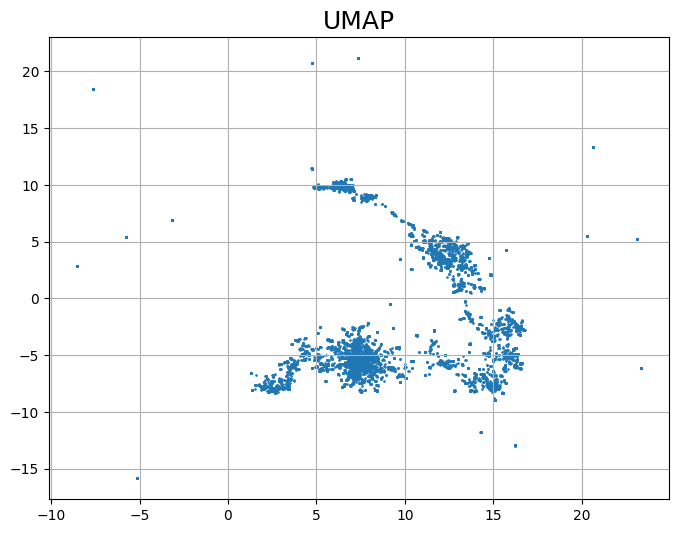

In [86]:
#Plotting the projection of data:
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection[:, 0], umap_2D_projection[:, 1], s=0.8)
plt.title("UMAP", fontsize=18)
plt.grid()
plt.show()

#### Clustering Algorithm results:

##### KMeans

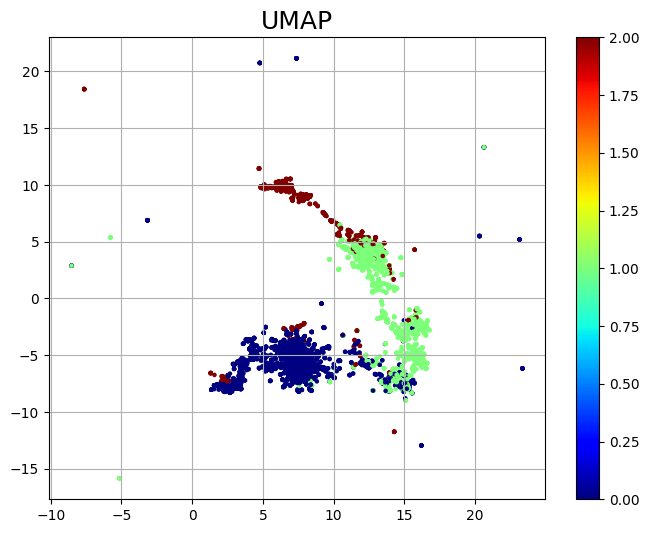

In [87]:
#KMeans as a simple version first:
kmeans = cluster.KMeans(n_clusters=3, n_init="auto").fit(image_pixel_dataframe_norm)
colours = kmeans.labels_
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection[:, 0], umap_2D_projection[:, 1], s=5, c = colours, cmap="jet")
plt.colorbar()
plt.title("UMAP", fontsize=18)
plt.grid()
plt.show()

(10.0, 70.0)

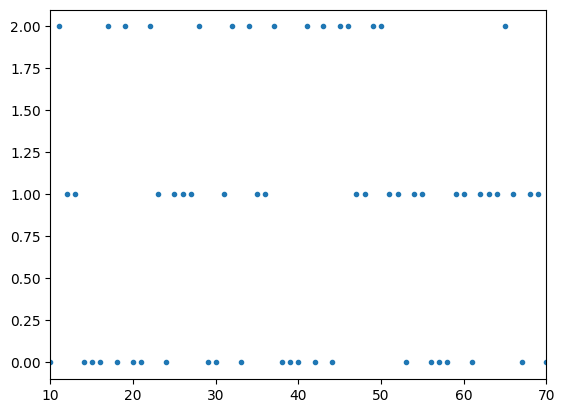

In [68]:
#Plotting the labels to check for patterns:
plt.plot(kmeans.labels_, ".")
plt.xlim(10, 70)

##### DBSCAN

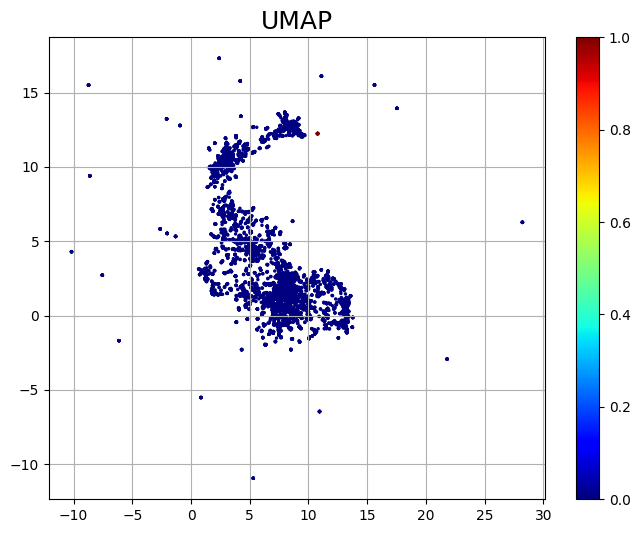

In [69]:
dbscan = cluster.DBSCAN(eps=0.5, min_samples=15).fit(image_pixel_dataframe_norm)
colours_db = dbscan.labels_+1
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection[:, 0], umap_2D_projection[:, 1], s=2.2, c = colours_db, cmap="jet")
plt.colorbar()
plt.title("UMAP", fontsize=18)
plt.grid()
plt.show()

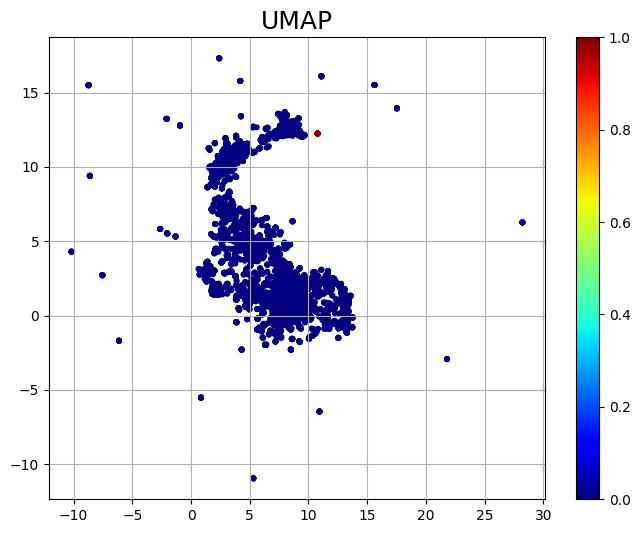

In [70]:
colours_db = dbscan.labels_+1
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection[:, 0], umap_2D_projection[:, 1], s=10.8, c = colours_db, cmap="jet")
plt.colorbar()
plt.title("UMAP", fontsize=18)
plt.grid()
plt.show()

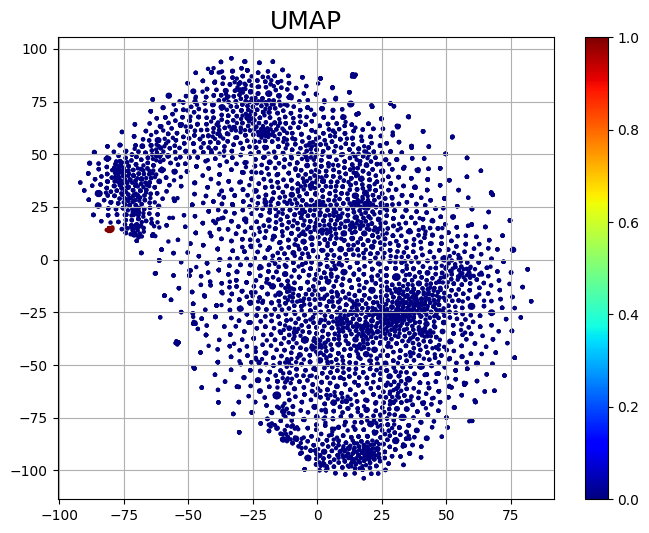

In [ ]:
colours_db = dbscan.labels_+1
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection[:, 0], umap_2D_projection[:, 1], s=10.8, c = colours_db, cmap="jet")
plt.colorbar()
plt.title("UMAP", fontsize=18)
plt.grid()
plt.show()

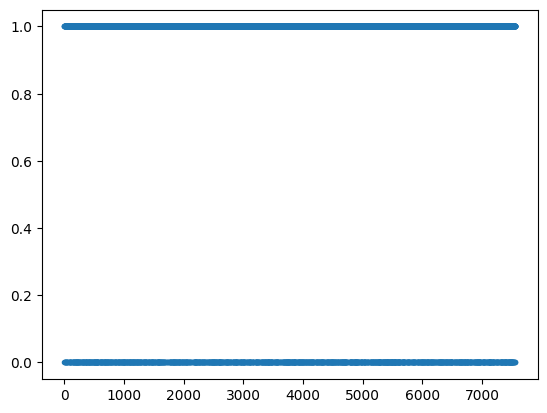

In [23]:
plt.plot(dbscan.labels_+1, ".")

#### Spectral clustering

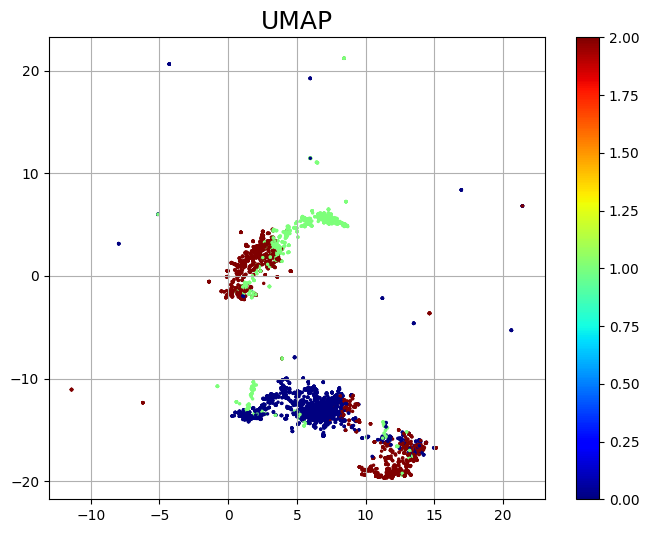

In [24]:
spectral = cluster.SpectralClustering(assign_labels="discretize", n_clusters=3, random_state=42).fit(image_pixel_dataframe_norm)
colours_spec = spectral.labels_
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection[:, 0], umap_2D_projection[:, 1], s=2.2, c = colours_spec, cmap="jet")
plt.colorbar()
plt.title("UMAP", fontsize=18)
plt.grid()
plt.show()

#### Optics

In [25]:
optics = cluster.OPTICS(min_samples=5).fit(image_pixel_dataframe_norm[:1000])
colours_opt = optics.labels_
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection[:, 0][:1000], umap_2D_projection[:, 1][:1000], s=2.2, c = colours_opt, cmap="jet")
plt.colorbar()
plt.title("UMAP", fontsize=18)
plt.grid()
plt.show()

KeyboardInterrupt: 

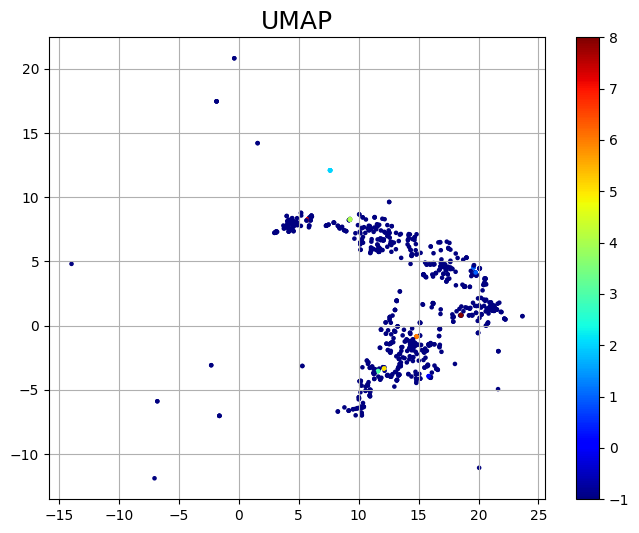

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection[:, 0][:1000], umap_2D_projection[:, 1][:1000], s=5.2, c = colours_opt, cmap="jet")
plt.colorbar()
plt.title("UMAP", fontsize=18)
plt.grid()
plt.show()

ANYTHING THAT RELATES TO DBSCAN IS TERRIBLE(Note: This comment may not be deleted under any circumstances)

### Trying sklearns dedicated outlier detection tools:

#### IsolationForest

In [131]:
iso_forest = IsolationForest(max_samples=250, n_estimators=500, max_features=3, random_state=42)
iso_forest.fit(image_pixel_dataframe_norm)
isolated_forest = iso_forest.predict(image_pixel_dataframe_norm)

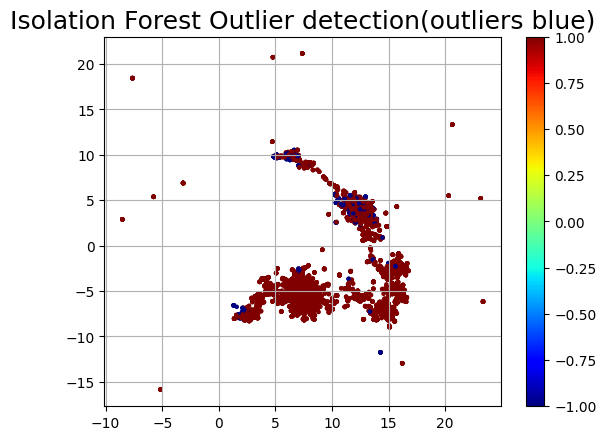

In [132]:
plt.scatter(umap_2D_projection[:, 0], umap_2D_projection[:, 1], s=5.2, c = isolated_forest, cmap="jet")
plt.colorbar()
plt.title("Isolation Forest Outlier detection(outliers blue)", fontsize=18)
plt.grid()
plt.show()

In [139]:
numpy_image_pixel_comp[colours_db == 1].T[-1]

array(['2025-10-03___7_left.webp', '2025-10-18___3_left.webp',
       '2025-10-19___4_right.webp', '2025-11-28___6_right.webp',
       '2025-12-19___0_right.webp', '2025-12-19___1_right.webp',
       '2025-12-19___2_left.webp', '2025-12-19___3_left.webp',
       '2025-12-19___4_left.webp', '2025-12-19___5_left.webp',
       '2025-12-19___6_right.webp', '2025-12-19___7_right.webp',
       '2025-12-19___8_right.webp', '2025-12-19___9_left.webp',
       '2026-03-20___6_left.webp', '2026-04-07___1_left.webp'],
      dtype=object)

#### Local Outlier Factor

In [171]:
factor_algo = LocalOutlierFactor(n_neighbors=10)
factor_algo_results = factor_algo.fit_predict(image_pixel_dataframe_norm)

c:\Users\Chris\anaconda3\envs\PYTHON313\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


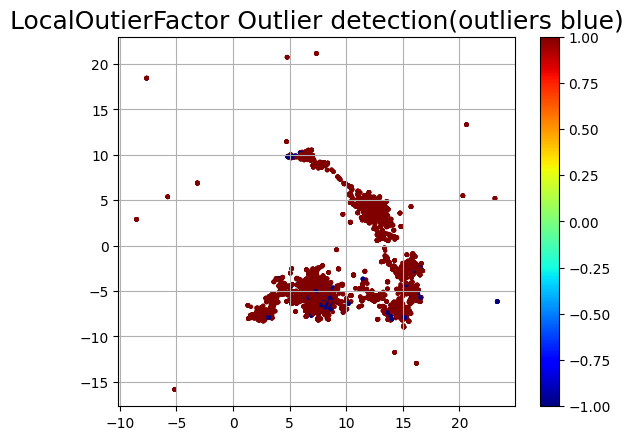

In [172]:
plt.scatter(umap_2D_projection[:, 0], umap_2D_projection[:, 1], s=5.2, c = factor_algo_results, cmap="jet")
plt.colorbar()
plt.title("LocalOutierFactor Outlier detection(outliers blue)", fontsize=18)
plt.grid()
plt.show()

In [179]:
numpy_image_pixel_comp[factor_algo_results == -1].T[-1][210]

'2026-01-19___1_right.webp'

In [176]:
np.argmax(umap_2D_projection[:, 0][factor_algo_results == -1])

np.int64(210)

In [178]:
umap_2D_projection[:, 0][factor_algo_results == -1][210]

np.float32(23.343792)

### Doing stuff with the limited non-image data:


In [181]:
non_image_vars = ["year", "rating", "price"]
low_var_image_pixel = image_pixel_dataframe_no_NaN[non_image_vars]


In [182]:
#Normalizing the data:
image_pixel_low_var_dataframe_norm = pd.DataFrame(preprocessing.normalize(low_var_image_pixel))

In [183]:
image_pixel_low_var_dataframe_norm

,0,1,2
0,0.999918,0.012759,0.001286
1,0.998988,0.044740,0.004691
2,0.999870,0.016071,0.001385
3,0.999197,0.040027,0.001680
4,0.998982,0.045036,0.002716
...,...,...,...
7549,0.999969,0.007385,0.002570
7550,0.999898,0.014169,0.001678
7551,0.999615,0.027605,0.002714
7552,0.999631,0.025910,0.008133


In [184]:
umap_projector_low_var = umap.UMAP(n_components=2, n_neighbors=50, random_state=42).fit(image_pixel_low_var_dataframe_norm)
umap_2D_projection_low_var = umap_projector_low_var.fit_transform(image_pixel_low_var_dataframe_norm)

c:\Users\Chris\anaconda3\envs\PYTHON313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


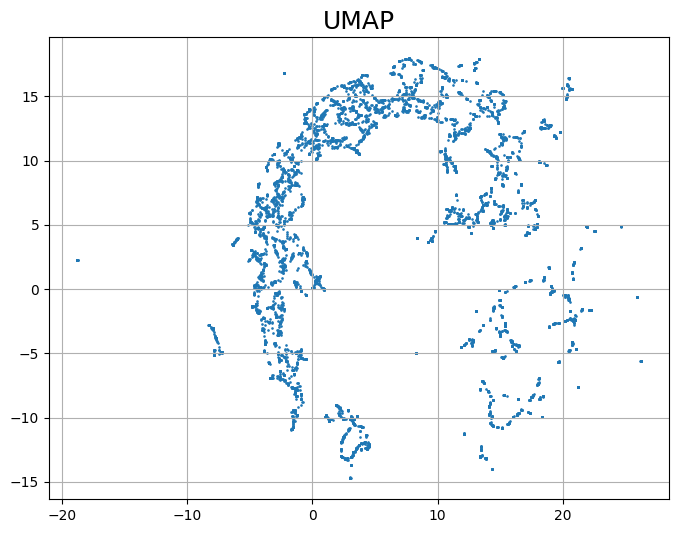

In [185]:
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection_low_var[:, 0], umap_2D_projection_low_var[:, 1], s=0.8)
plt.title("UMAP", fontsize=18)
plt.grid()
plt.show()

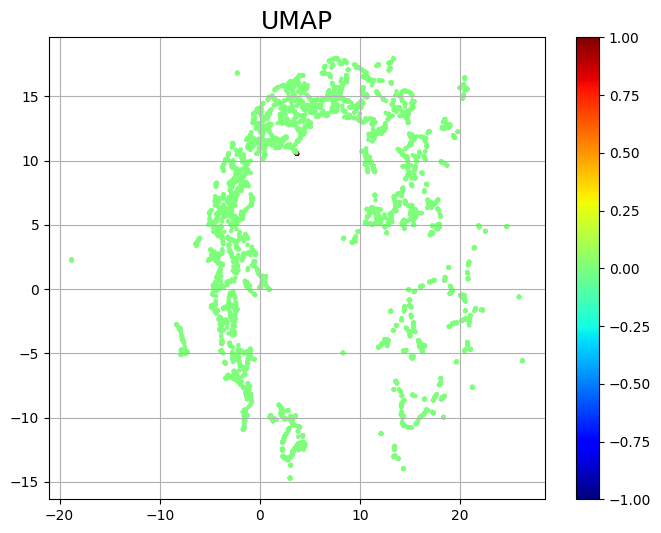

In [208]:
kmeans = cluster.DBSCAN(eps=0.03).fit(image_pixel_low_var_dataframe_norm)
colours = kmeans.labels_
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection_low_var[:, 0], umap_2D_projection_low_var[:, 1], s=5, c = colours, cmap="jet")
plt.colorbar()
plt.title("UMAP", fontsize=18)
plt.grid()
plt.show()

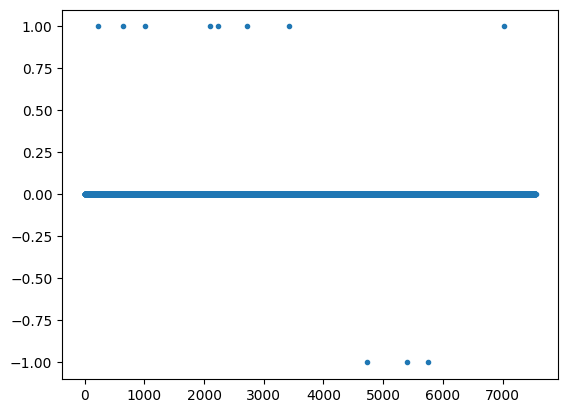

In [209]:
plt.plot(kmeans.labels_, ".")